# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

Matplotlib is building the font cache; this may take a moment.


00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [2]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [3]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [4]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [5]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


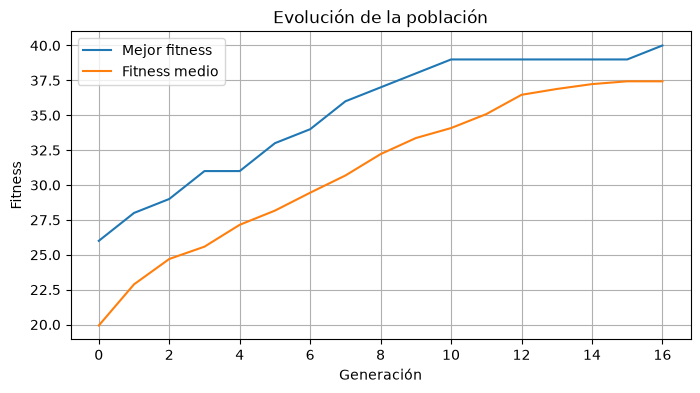

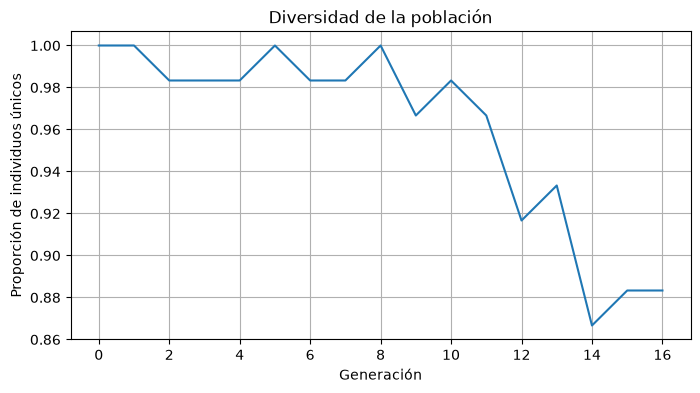

In [6]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [7]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [8]:
def roulette_selection(population, rng):
    fitness_values = [fitness(individual) for individual in population]
    total_fitness = sum(fitness_values)

    if total_fitness == 0:
        return rng.choice(population)

    selected = rng.uniform(0, total_fitness)
    accumulated = 0

    for individual, fit in zip(population, fitness_values):
        accumulated += fit

        if accumulated >= selected:
            return individual

    return population[-1]

### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [9]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []

    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    return child1, child2

### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [11]:
TARGET = "INTELIGENCIA ARTIFICIAL"
ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ "

def create_phrase_individual(rng):
    return [rng.choice(ALPHABET) for _ in range(len(TARGET))]


def phrase_fitness(individual):
    return sum(
        gene == target
        for gene, target in zip(individual, TARGET)
    )


def phrase_selection(population, rng):
    fitness_values = [phrase_fitness(ind) for ind in population]
    total_fitness = sum(fitness_values)

    if total_fitness == 0:
        return rng.choice(population)

    selected = rng.uniform(0, total_fitness)
    accumulated = 0

    for individual, fit in zip(population, fitness_values):
        accumulated += fit

        if accumulated >= selected:
            return individual

    return population[-1]


def phrase_mutation(individual, mutation_rate, rng):
    child = individual.copy()

    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)

    return child


def phrase_genetic_algorithm(
    population_size=200,
    generations=5000,
    crossover_rate=0.9,
    mutation_rate=0.05
):
    rng = random.Random(SEED)

    population = [
        create_phrase_individual(rng)
        for _ in range(population_size)
    ]

    for generation in range(generations + 1):
        population.sort(key=phrase_fitness, reverse=True)

        best = population[0]
        best_fitness = phrase_fitness(best)

        if generation % 20 == 0 or best_fitness == len(TARGET):
            print(
                f"Generación {generation}: "
                f"{''.join(best)} "
                f"fitness = {best_fitness}/{len(TARGET)}"
            )

        if best_fitness == len(TARGET):
            return best

        new_population = [best.copy()]

        while len(new_population) < population_size:
            parent1 = phrase_selection(population, rng)
            parent2 = phrase_selection(population, rng)

            child1, child2 = uniform_crossover(
                parent1,
                parent2,
                crossover_rate,
                rng
            )

            child1 = phrase_mutation(child1, mutation_rate, rng)
            child2 = phrase_mutation(child2, mutation_rate, rng)

            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return population[0]


best_phrase = phrase_genetic_algorithm()

print("\nMejor frase encontrada:", ''.join(best_phrase))

Generación 0: TUGRLILBKCIILMQDGTJWBYN fitness = 4/23
Generación 20: PNQSLIGCOCIF KRTIAICIAL fitness = 15/23
Generación 40: INTEEIG HFIF GRTIFICIAL fitness = 17/23
Generación 60: INTEEIG HFIF GRTIFICIAL fitness = 17/23
Generación 80: INTEEIG HFIF GRTIFICIAL fitness = 17/23
Generación 100: INTEEIG HFIF GRTIFICIAL fitness = 17/23
Generación 120: INTELICOUCIA ARTILIMIAL fitness = 18/23
Generación 140: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 160: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 180: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 200: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 220: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 240: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 260: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 280: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 300: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 320: INTELICBUCIA ARTIFIMIAL fitness = 19/23
Generación 340: INTELIBECCIA ARTIFNCIAL fitness = 20/23

### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

In [12]:
def compare_elitism(
    population_size=80,
    generations=120,
    crossover_rate=0.9,
    mutation_rate=0.08
):
    def run(use_elitism):
        rng = random.Random(SEED)

        population = [
            create_phrase_individual(rng)
            for _ in range(population_size)
        ]

        best_history = []

        for generation in range(generations):
            population.sort(key=phrase_fitness, reverse=True)

            best = population[0]
            best_history.append(phrase_fitness(best))

            new_population = []

            if use_elitism:
                new_population.append(best.copy())

            while len(new_population) < population_size:
                parent1 = phrase_selection(population, rng)
                parent2 = phrase_selection(population, rng)

                child1, child2 = uniform_crossover(
                    parent1,
                    parent2,
                    crossover_rate,
                    rng
                )

                child1 = phrase_mutation(child1, mutation_rate, rng)
                child2 = phrase_mutation(child2, mutation_rate, rng)

                new_population.append(child1)

                if len(new_population) < population_size:
                    new_population.append(child2)

            population = new_population

        return best_history

    with_elitism = run(True)
    without_elitism = run(False)

    decreases_with = sum(
        with_elitism[i] < with_elitism[i - 1]
        for i in range(1, len(with_elitism))
    )

    decreases_without = sum(
        without_elitism[i] < without_elitism[i - 1]
        for i in range(1, len(without_elitism))
    )

    print("Con elitismo:")
    print("Disminuciones del mejor fitness:", decreases_with)

    print("\nSin elitismo:")
    print("Disminuciones del mejor fitness:", decreases_without)

    print("\nMejor fitness final con elitismo:", with_elitism[-1])
    print("Mejor fitness final sin elitismo:", without_elitism[-1])


compare_elitism()

Con elitismo:
Disminuciones del mejor fitness: 0

Sin elitismo:
Disminuciones del mejor fitness: 30

Mejor fitness final con elitismo: 15
Mejor fitness final sin elitismo: 12


## Preguntas de cierre

1. ¿Qué papel cumple la población que no existe en Hill Climbing?
2. ¿Por qué el cruce no garantiza hijos mejores que sus padres?
3. ¿Qué significa convergencia prematura?
4. ¿Qué parámetros controlan la exploración?

### Respuestas

1. **¿Qué papel cumple la población que no existe en Hill Climbing?**

   La población permite trabajar con varias soluciones al mismo tiempo. Esto aumenta la diversidad y permite explorar diferentes zonas del espacio de búsqueda, mientras que Hill Climbing trabaja principalmente con una sola solución.

2. **¿Por qué el cruce no garantiza hijos mejores que sus padres?**

   Porque el cruce combina genes de los padres de forma aleatoria. Esa combinación puede producir un hijo mejor, igual o peor que sus padres.

3. **¿Qué significa convergencia prematura?**

   Ocurre cuando la población pierde diversidad demasiado rápido y termina concentrándose en soluciones parecidas antes de encontrar una solución óptima.

4. **¿Qué parámetros controlan la exploración?**

   Principalmente el tamaño de la población, la tasa de mutación, la tasa de cruce y la presión de selección. Estos parámetros determinan cuánta variedad se genera y cuánto se exploran nuevas soluciones.
   